<a href="https://colab.research.google.com/github/meganjohnson0522/INFO648/blob/main/Lesson_02/INFO648_LSN2_Student.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import requests

The data for this notebook comes from two places- the fisr is the BLS API -but it only provides aggregated data.  To get the individual datat that the BLS uses I had to use https://cps.ipums.org/cps/

In [ ]:
#We need to tell python which libraries we want to use
#in this case we will need pandas to work with data and request to pull data from an API.

Where does data come from - usually a cloud server, a database, sometimes when two files fall in love.....

Below we use the Beurueu of Labor and Statistics API - it is a behometh.  There are thousands of columns of data - each column has a unique ***series***. Here we are telling the series we want to look at (it took me some time to find this - Chat at Gemini still are horrible at this sort of research).
Let me explain these series:
This link brings us to the BLS. https://data.bls.gov/series-report
The series represents an aggrigated data record for a year group of years:

- **Series Id:** LEU0252919100  
- **Seasonal Adjustment:** Not Seasonally Adjusted  
- **Series Title:** (unadj) Median usual weekly earnings (second quartile), Employed full time, Wage and salary workers, Bachelor's degree only, 25 years and over  
- **Earnings Measure:** Median usual weekly earnings (second quartile)  
- **Units:** Current dollars (weekly)  
- **Industry:** All Industries  
- **Occupation:** All Occupations  
- **Sex:** Both Sexes  
- **Race:** All Races  
- **Ethnic Origin:** All Origins  
- **Age:** 25 years and over  
- **Education:** Bachelor's degree only  
- **Class of Worker:** Wage and salary workers, excluding incorporated self-employed  
- **Labor Force Status:** Employed full time  


LEU0252911300 - 25 Percentile all workers
LEU0252911400 - 75 Percentile all workers

In [ ]:
#BLS data is based on series and instead of typing them in in class I give them to you.
#This is a dictionary when the Key is the name and the Series is the value.
series_ids = {
    "Bachelors_Only":"LEU0252919100",
    "Bachelors_Plus": "LEU0252918500",
    "HS_Grad": "LEU0252917300",
    "Less_than_HS": "LEU0252916700",
    "Men_Bachelors_Plus": "LEU0252922500",
    "Women_Bachelors_Plus": "LEU0252926500",
    "HS_Grad_Cert":"LEU0259295900"

}

start_year = 2015
end_year = 2025

In [ ]:
#Let's discuss dictionaries in this cell
#Dictionary in python - uses {} and is just key value paris

series_ids

{'Bachelors_Only': 'LEU0252919100',
 'Bachelors_Plus': 'LEU0252918500',
 'HS_Grad': 'LEU0252917300',
 'Less_than_HS': 'LEU0252916700',
 'Men_Bachelors_Plus': 'LEU0252922500',
 'Women_Bachelors_Plus': 'LEU0252926500',
 'HS_Grad_Cert': 'LEU0259295900'}

Here we conduct an API call - if you do a really big pull (more than 10 years) you have to register - but we are only doing 10 years.  APIs love JSON - so the data comes back in what looks like a python dictionary and it is kinda like one - a JSON object is a series of key:value pairs in quotes seperated by a colon.

In [ ]:
#this is the BLS URL
url = "https://api.bls.gov/publicAPI/v2/timeseries/data/"
#This is just the required information we need to use the BLS API - I took this
#from the BLS webpage
payload = {
    "seriesid": list(series_ids.values()),
    "startyear": start_year,
    "endyear": end_year
}
#this is the API call - lets go get some data.
response = requests.post(url, json=payload)
#The data comes to us in JSON -
data = response.json()


Now we have a JSON Object - great for computers...not great for me.  Notice it is a series of key value pairs - this is oftern how API data comes back to us. There was a time I hacked away to convert this - but AI does it quite well.

In [ ]:
data


{'status': 'REQUEST_SUCCEEDED',
 'responseTime': 233,
 'message': ['Year range has been reduced to the system-allowed limit of 10 years.'],
 'Results': {'series': [{'seriesID': 'LEU0252919100',
    'data': [{'year': '2024',
      'period': 'Q04',
      'periodName': '4th Quarter',
      'value': '1547',
      'footnotes': [{}]},
     {'year': '2024',
      'period': 'Q03',
      'periodName': '3rd Quarter',
      'value': '1533',
      'footnotes': [{}]},
     {'year': '2024',
      'period': 'Q02',
      'periodName': '2nd Quarter',
      'value': '1541',
      'footnotes': [{}]},
     {'year': '2024',
      'period': 'Q01',
      'periodName': '1st Quarter',
      'value': '1551',
      'footnotes': [{}]},
     {'year': '2023',
      'period': 'Q04',
      'periodName': '4th Quarter',
      'value': '1509',
      'footnotes': [{}]},
     {'year': '2023',
      'period': 'Q03',
      'periodName': '3rd Quarter',
      'value': '1499',
      'footnotes': [{}]},
     {'year': '2023',
  

In [ ]:
#I stole this from BLS API and Chat GPT - we are just orgamizing the data
#from the JSON format to a nicer format for analysis.
records = []

for series in data['Results']['series']:
    series_name = [k for k, v in series_ids.items() if v == series['seriesID']][0]

    for item in series['data']:
        records.append({
            "Year": int(item['year']),
            "Period": item['period'],
            "Value": float(item['value']),
            "Series": series_name
        })


In [ ]:
records

[{'Year': 2024, 'Period': 'Q04', 'Value': 1547.0, 'Series': 'Bachelors_Only'},
 {'Year': 2024, 'Period': 'Q03', 'Value': 1533.0, 'Series': 'Bachelors_Only'},
 {'Year': 2024, 'Period': 'Q02', 'Value': 1541.0, 'Series': 'Bachelors_Only'},
 {'Year': 2024, 'Period': 'Q01', 'Value': 1551.0, 'Series': 'Bachelors_Only'},
 {'Year': 2023, 'Period': 'Q04', 'Value': 1509.0, 'Series': 'Bachelors_Only'},
 {'Year': 2023, 'Period': 'Q03', 'Value': 1499.0, 'Series': 'Bachelors_Only'},
 {'Year': 2023, 'Period': 'Q02', 'Value': 1467.0, 'Series': 'Bachelors_Only'},
 {'Year': 2023, 'Period': 'Q01', 'Value': 1488.0, 'Series': 'Bachelors_Only'},
 {'Year': 2022, 'Period': 'Q04', 'Value': 1435.0, 'Series': 'Bachelors_Only'},
 {'Year': 2022, 'Period': 'Q03', 'Value': 1452.0, 'Series': 'Bachelors_Only'},
 {'Year': 2022, 'Period': 'Q02', 'Value': 1441.0, 'Series': 'Bachelors_Only'},
 {'Year': 2022, 'Period': 'Q01', 'Value': 1395.0, 'Series': 'Bachelors_Only'},
 {'Year': 2021, 'Period': 'Q04', 'Value': 1351.0, 'S

Now we are going to put this into a pandas data frame - Pandas makes nice tables - like DPLYR in R, or kinda like Excel. This data is now in a Tidy or Long format.  

In [ ]:
# We want to put the data into a data frame.
#Lets do this together

df_long = pd.DataFrame(records)


In [ ]:
df_long.head()

,Year,Period,Value,Series
0,2024,Q04,1547.0,Bachelors_Only
1,2024,Q03,1533.0,Bachelors_Only
2,2024,Q02,1541.0,Bachelors_Only
3,2024,Q01,1551.0,Bachelors_Only
4,2023,Q04,1509.0,Bachelors_Only


I do not want quarterly data - I want to aggregate my data to the annual level - so lets use our sql skills - we are going to group by. we have to reset_index or the indexing gets screwed up

In [ ]:
#OK, most of us have seen SQL and I believe it is the work horse of data analysis - lets use
# a group by to get rid of the quarters and aggregate to the year.

df_annual = df_long.groupby(['Year', 'Series'])['Value'].mean().reset_index()

In [ ]:
df_annual.head(10)

,Year,Series,Value
0,2015,Bachelors_Only,1137.50
1,2015,Bachelors_Plus,1229.00
2,2015,HS_Grad,677.25
3,2015,HS_Grad_Cert,772.00
4,2015,Less_than_HS,492.75
5,2015,Men_Bachelors_Plus,1420.25
6,2015,Women_Bachelors_Plus,1063.50
7,2016,Bachelors_Only,1155.75
8,2016,Bachelors_Plus,1258.75
9,2016,HS_Grad,691.75


In [ ]:
#The data is in a format called Tidy data - which is great for storage and ML models, but
#not great for plotting.  So we are going to use a pivot command - we want the
#Different Series to each be a column - kinda like in excel and we want the Values
#to be in the chart.

df_wide = df_annual.pivot(
    index='Year',
    columns='Series',
    values='Value'
).reset_index()


In [ ]:
df_wide

Series,Year,Bachelors_Only,Bachelors_Plus,HS_Grad,HS_Grad_Cert,Less_than_HS,Men_Bachelors_Plus,Women_Bachelors_Plus
0,2015,1137.50,1229.00,677.25,772.0,492.75,1420.25,1063.50
1,2016,1155.75,1258.75,691.75,795.0,504.00,1463.50,1101.00
2,2017,1175.50,1279.75,712.00,812.0,520.00,1482.75,1130.50
3,2018,1198.25,1318.50,730.25,837.0,554.00,1520.75,1144.50
4,2019,1247.25,1368.00,746.50,853.0,592.00,1574.00,1198.50
5,2020,1301.00,1420.00,782.50,908.0,622.25,1641.50,1234.75
6,2021,1329.75,1451.25,808.25,937.0,629.25,1661.50,1282.25
7,2022,1430.75,1543.75,851.50,982.0,681.50,1766.50,1373.00
8,2023,1490.75,1609.25,898.75,1029.0,707.25,1860.00,1436.00
9,2024,1543.00,1691.50,935.00,1083.0,738.50,1906.75,1479.00


<Axes: xlabel='Year'>

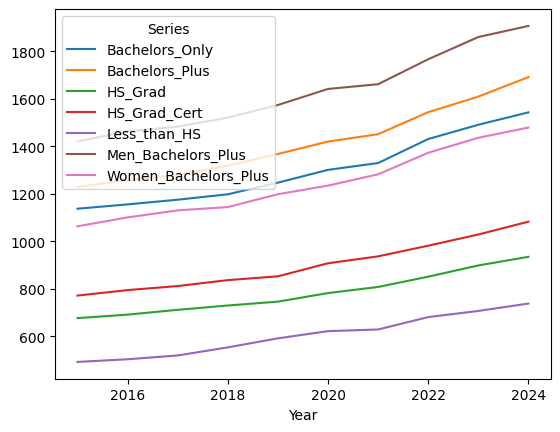

In [ ]:
#I want to see if Grad school is worth the effort for salary. Maybe if we look at all
#the salaries by education level over the years we can learn something.
# We will use the plot command that is built in pandas.

df_wide.plot(
    x = 'Year',
    y = ['Bachelors_Only', 'Bachelors_Plus', 'HS_Grad', 'HS_Grad_Cert', 'Less_than_HS', 'Men_Bachelors_Plus',	'Women_Bachelors_Plus'],
    kind = 'line'
)


In [ ]:
df_wide.tail()

BREAK - BELOW THIS IS DAY 3
